Relative error (%) = 28.73
Max abs error      = 1.8082
Beta0              = -0.950439


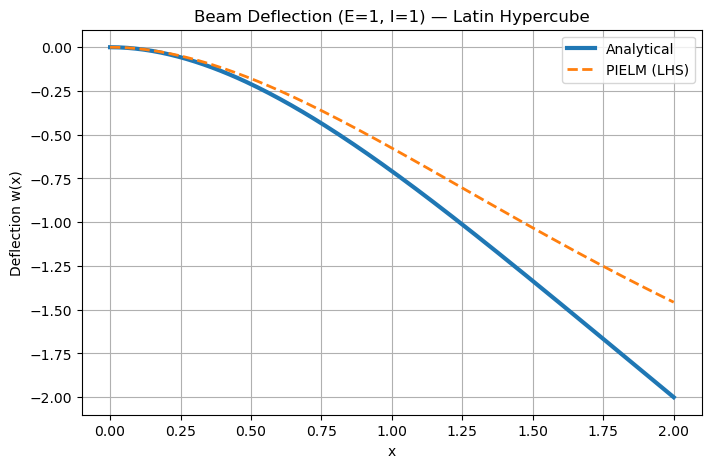

In [8]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

torch.set_default_dtype(torch.float32)

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    xbar = xei[:,0:1] / L
    Ehat = 2*(xei[:,1:2]-E_range[0])/(E_range[1]-E_range[0]) - 1
    Ihat = 2*(xei[:,2:3]-I_range[0])/(I_range[1]-I_range[0]) - 1
    return torch.cat([xbar, Ehat, Ihat], dim=1)

# =============================================================================
# DERIVATIVES wrt x
# =============================================================================
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:,0:1]
    return cur

# =============================================================================
# TRAINING WITH LATIN HYPERCUBE SAMPLING
# =============================================================================
def train_pielm_lhs(hidden_size=40, seed=0, lambda_reg=1.0,
                    gauss_scale=0.5, n_lhs=4000, n_bc=200):

    torch.manual_seed(seed)

    # Gaussian ELM parameters
    W = torch.randn(3, hidden_size) * 0.1
    b = torch.randn(hidden_size) * 0.1

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # -------------------------------------------------------------------------
    # LATIN HYPERCUBE SAMPLING (FLOAT32 FIX)
    # -------------------------------------------------------------------------
    sampler = qmc.LatinHypercube(d=3, seed=seed)
    lhs = sampler.random(n_lhs)

    x = torch.tensor(lhs[:,0:1], dtype=torch.float32) * L
    E = E_range[0] + torch.tensor(lhs[:,1:2], dtype=torch.float32) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.tensor(lhs[:,2:3], dtype=torch.float32) * (I_range[1]-I_range[0])

    xei = torch.cat([x, E, I], dim=1).requires_grad_(True)

    # -------------------------------------------------------------------------
    # BC-EMBEDDED TRIAL FUNCTION (dimensionless wbar)
    # -------------------------------------------------------------------------
    xbar = xei[:,0:1] / L
    H = activation(normalize(xei) @ W + b)
    Phi = (xbar**2) * H
    Phi_aug = torch.hstack([Phi, xbar**2])   # beta0 term

    # -------------------------------------------------------------------------
    # PDE: L^4 * wbar_xxxx = 1
    # -------------------------------------------------------------------------
    Acols = []
    for j in range(hidden_size+1):
        w4 = derivative(Phi_aug[:,j:j+1], xei, 4)
        Acols.append((L**4) * w4)

    A_pde = torch.hstack(Acols)
    b_pde = torch.ones(A_pde.shape[0],1)

    # -------------------------------------------------------------------------
    # BOUNDARY CONDITIONS at x = L
    # -------------------------------------------------------------------------
    sampler_bc = qmc.LatinHypercube(d=2, seed=seed+10)
    lhs_bc = sampler_bc.random(n_bc)

    Ebc = E_range[0] + torch.tensor(lhs_bc[:,0:1], dtype=torch.float32) * (E_range[1]-E_range[0])
    Ibc = I_range[0] + torch.tensor(lhs_bc[:,1:2], dtype=torch.float32) * (I_range[1]-I_range[0])
    xL = torch.ones(n_bc,1) * L

    xeiL = torch.cat([xL, Ebc, Ibc], dim=1).requires_grad_(True)

    xbarL = xeiL[:,0:1] / L
    HL = activation(normalize(xeiL) @ W + b)
    PhiL = (xbarL**2) * HL
    PhiL_aug = torch.hstack([PhiL, xbarL**2])

    BC2, BC3 = [], []
    for j in range(hidden_size+1):
        BC2.append(derivative(PhiL_aug[:,j:j+1], xeiL, 2))
        BC3.append(derivative(PhiL_aug[:,j:j+1], xeiL, 3))

    C = torch.vstack([torch.hstack(BC2), torch.hstack(BC3)])
    d = torch.zeros(C.shape[0],1)

    # -------------------------------------------------------------------------
    # KKT SYSTEM
    # -------------------------------------------------------------------------
    A_T = A_pde.T
    C_T = C.T

    KKT_top = torch.hstack([A_T@A_pde + lambda_reg*torch.eye(hidden_size+1), C_T])
    KKT_bot = torch.hstack([C, torch.zeros((C.shape[0],C.shape[0]))])
    KKT = torch.vstack([KKT_top, KKT_bot])

    rhs = torch.vstack([A_T@b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)
    beta_aug = sol[:hidden_size+1]
    beta = beta_aug[:-1]
    beta0 = beta_aug[-1].item()

    # -------------------------------------------------------------------------
    # PHYSICAL DEFLECTION PREDICTOR
    # -------------------------------------------------------------------------
    def predict(xei):
        xbar = xei[:,0:1] / L
        Hq = activation(normalize(xei) @ W + b)
        wbar = (xbar**2) * (Hq @ beta + beta0)
        return (Q * L**4 / (xei[:,1:2] * xei[:,2:3])) * wbar

    return predict, beta0

# =============================================================================
# VALIDATION
# =============================================================================
def validate(predict, n_test=5000):
    x = torch.rand(n_test,1) * L
    E = E_range[0] + torch.rand(n_test,1)*(E_range[1]-E_range[0])
    I = I_range[0] + torch.rand(n_test,1)*(I_range[1]-I_range[0])
    xei = torch.cat([x,E,I], dim=1)

    w_pred = predict(xei)
    w_exact = analytical_solution(x,E,I)

    rel = torch.norm(w_pred - w_exact) / torch.norm(w_exact)
    max_abs = torch.max(torch.abs(w_pred - w_exact)).item()
    return rel.item(), max_abs

# =============================================================================
# TRAIN & TEST
# =============================================================================
predict, beta0 = train_pielm_lhs(
    hidden_size=40,
    seed=0,
    lambda_reg=1.0,
    gauss_scale=0.5,
    n_lhs=4000
)

rel_err, max_abs = validate(predict)
print(f"Relative error (%) = {rel_err*100:.2f}")
print(f"Max abs error      = {max_abs:.4f}")
print(f"Beta0              = {beta0:.6f}")

# =============================================================================
# PLOTS (E=1, I=1)
# =============================================================================
x_plot = torch.linspace(0,L,200).reshape(-1,1)
xei_plot = torch.cat([x_plot,
                      torch.ones_like(x_plot),
                      torch.ones_like(x_plot)], dim=1)

w_pred = predict(xei_plot).detach().numpy().flatten()
w_exact = analytical_solution(x_plot,1.0,1.0).numpy().flatten()

plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy(), w_exact, label="Analytical", linewidth=3)
plt.plot(x_plot.numpy(), w_pred, "--", label="PIELM (LHS)", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Beam Deflection (E=1, I=1) — Latin Hypercube")
plt.legend()
plt.grid(True)
plt.show()


Relative error (%) = 2.00
RMSE               = 0.020431
Max abs error      = 0.168249
Beta0              = 0.279224


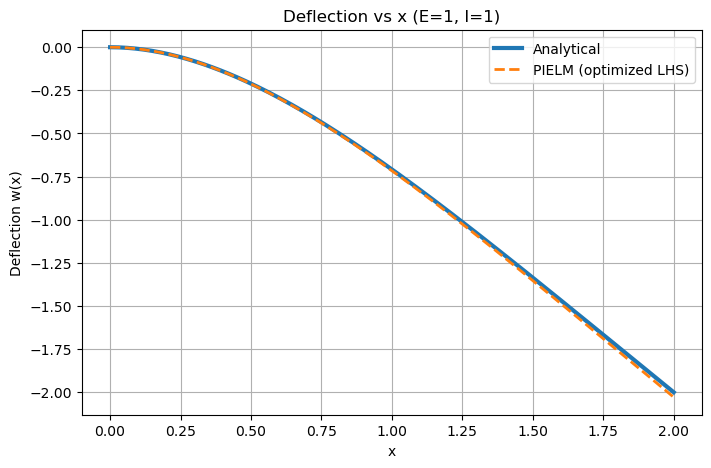

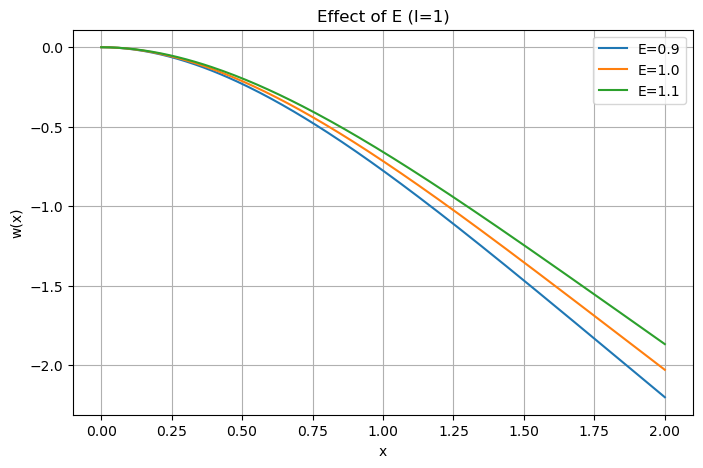

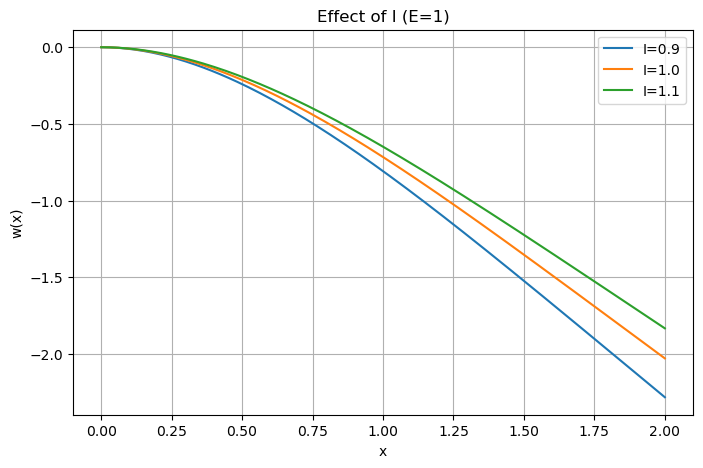

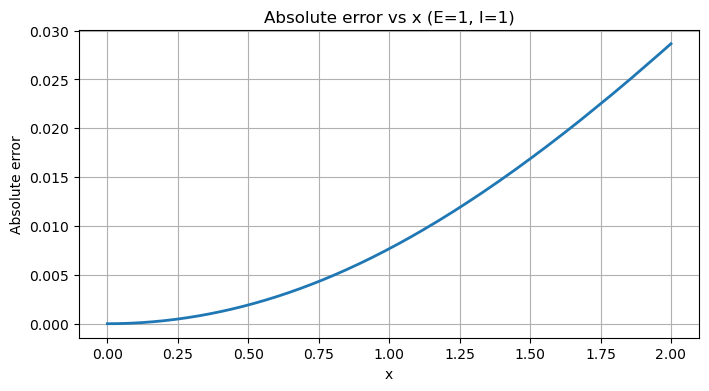


Computing mean/variance under uncertainty...


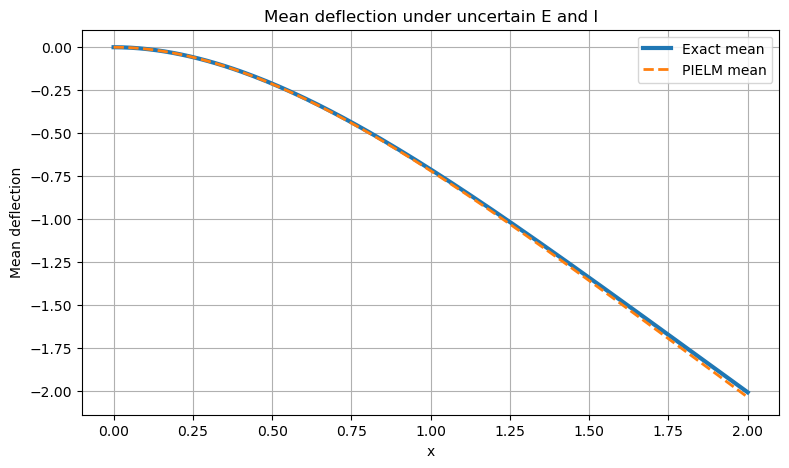

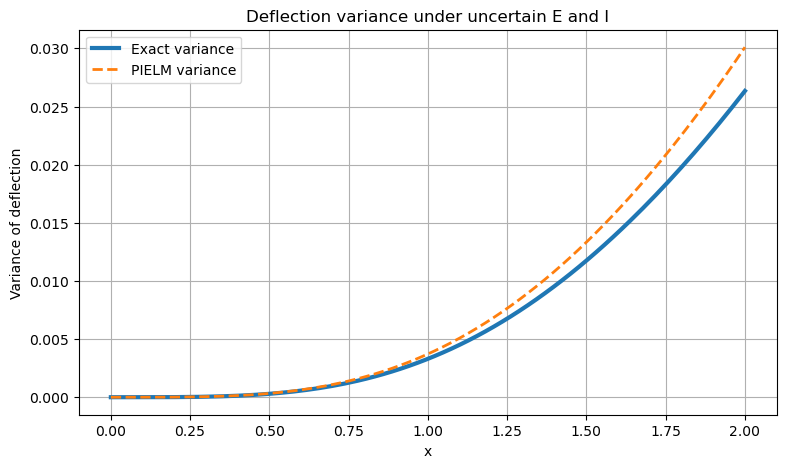


Plotting bell-shaped uncertainty distributions...


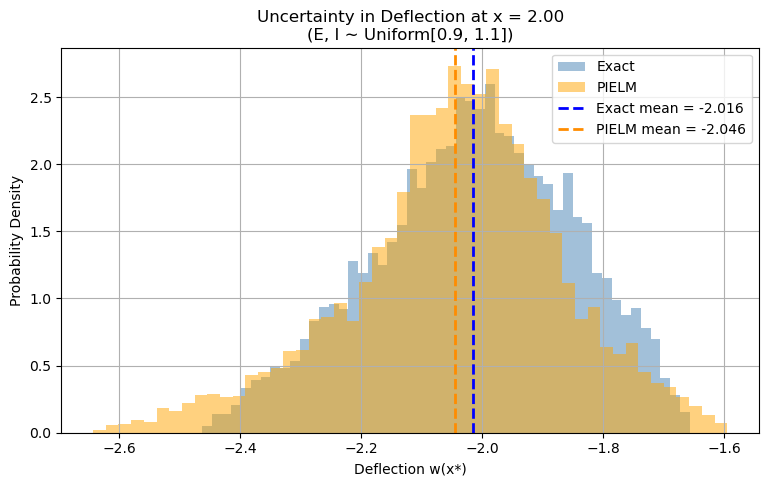

UNCERTAINTY STATISTICS (Bell Curve)
--------------------------------------------------
Location x*         = 2.0
Exact mean          = -2.015727
Exact std           = 0.164335
PIELM mean          = -2.045572
PIELM std           = 0.176803
Mean error (%)      = 1.48
Std error (%)       = 7.59


In [11]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

torch.set_default_dtype(torch.float32)

# =============================================================================
# PHYSICAL PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# EXACT SOLUTION (PHYSICAL)
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    xbar = xei[:, 0:1] / L
    Ehat = 2*(xei[:, 1:2]-E_range[0])/(E_range[1]-E_range[0]) - 1
    Ihat = 2*(xei[:, 2:3]-I_range[0])/(I_range[1]-I_range[0]) - 1
    return torch.cat([xbar, Ehat, Ihat], dim=1)

# =============================================================================
# DERIVATIVES wrt physical x
# =============================================================================
def derivative(u, xei, order):
    cur = u
    for _ in range(order):
        cur = autograd.grad(cur.sum(), xei, create_graph=True)[0][:, 0:1]
    return cur

# =============================================================================
# TRAINING WITH LHS (OPTIMIZED HYPERPARAMETERS + BC WEIGHTING)
# =============================================================================
def train_pielm_lhs_optimized(
    hidden_size=80,
    seed=0,
    lambda_reg=2.0,
    gauss_scale=0.30,
    n_lhs=12000,
    n_bc=400,
    bc_weight=20.0
):
    torch.manual_seed(seed)

    # Gaussian ELM parameters (force float32)
    W = (torch.randn(3, hidden_size, dtype=torch.float32) * 0.1)
    b = (torch.randn(hidden_size, dtype=torch.float32) * 0.1)

    def activation(z):
        return torch.exp(-(z/gauss_scale)**2)

    # -------------------------------------------------------------------------
    # LHS collocation points (x,E,I)  ---> IMPORTANT: cast to float32
    # -------------------------------------------------------------------------
    sampler = qmc.LatinHypercube(d=3, seed=seed)
    lhs = sampler.random(n_lhs)

    x = torch.tensor(lhs[:, 0:1], dtype=torch.float32) * L
    E = E_range[0] + torch.tensor(lhs[:, 1:2], dtype=torch.float32) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.tensor(lhs[:, 2:3], dtype=torch.float32) * (I_range[1]-I_range[0])

    xei = torch.cat([x, E, I], dim=1).requires_grad_(True)

    # -------------------------------------------------------------------------
    # BC-embedded trial for dimensionless wbar:
    #   wbar = xbar^2 * (H beta + beta0)
    # -------------------------------------------------------------------------
    xbar = xei[:, 0:1] / L
    H = activation(normalize(xei) @ W + b)
    Phi = (xbar**2) * H
    Phi_aug = torch.hstack([Phi, xbar**2])  # beta0 term

    # -------------------------------------------------------------------------
    # PDE: L^4 * (d^4 wbar / dx^4) = 1
    # -------------------------------------------------------------------------
    Acols = []
    for j in range(hidden_size + 1):
        w4 = derivative(Phi_aug[:, j:j+1], xei, 4)
        Acols.append((L**4) * w4)

    A_pde = torch.hstack(Acols)
    b_pde = torch.ones(A_pde.shape[0], 1, dtype=torch.float32)

    # Mild scaling for conditioning
    pde_scale = torch.mean(torch.abs(A_pde)).clamp_min(1e-8)
    A_pde = A_pde / pde_scale
    b_pde = b_pde / pde_scale

    # -------------------------------------------------------------------------
    # Boundary conditions at x=L (wbar''=0, wbar'''=0)
    # -------------------------------------------------------------------------
    sampler_bc = qmc.LatinHypercube(d=2, seed=seed + 123)
    lhs_bc = sampler_bc.random(n_bc)

    Ebc = E_range[0] + torch.tensor(lhs_bc[:, 0:1], dtype=torch.float32) * (E_range[1]-E_range[0])
    Ibc = I_range[0] + torch.tensor(lhs_bc[:, 1:2], dtype=torch.float32) * (I_range[1]-I_range[0])
    xL = torch.ones(n_bc, 1, dtype=torch.float32) * L

    xeiL = torch.cat([xL, Ebc, Ibc], dim=1).requires_grad_(True)

    xbarL = xeiL[:, 0:1] / L
    HL = activation(normalize(xeiL) @ W + b)
    PhiL = (xbarL**2) * HL
    PhiL_aug = torch.hstack([PhiL, xbarL**2])

    BC2, BC3 = [], []
    for j in range(hidden_size + 1):
        BC2.append(derivative(PhiL_aug[:, j:j+1], xeiL, 2))
        BC3.append(derivative(PhiL_aug[:, j:j+1], xeiL, 3))

    C = torch.vstack([torch.hstack(BC2), torch.hstack(BC3)])
    d = torch.zeros(C.shape[0], 1, dtype=torch.float32)

    # Scale BC equations & weight them
    bc_scale = torch.mean(torch.abs(C)).clamp_min(1e-8)
    C = (bc_weight / bc_scale) * C
    d = (bc_weight / bc_scale) * d

    # -------------------------------------------------------------------------
    # KKT SYSTEM
    # -------------------------------------------------------------------------
    A_T = A_pde.T
    C_T = C.T

    KKT_top = torch.hstack([A_T @ A_pde + lambda_reg * torch.eye(hidden_size + 1), C_T])
    KKT_bot = torch.hstack([C, torch.zeros((C.shape[0], C.shape[0]), dtype=torch.float32)])
    KKT = torch.vstack([KKT_top, KKT_bot])

    rhs = torch.vstack([A_T @ b_pde, d])

    sol = torch.linalg.solve(KKT, rhs)
    beta_aug = sol[:hidden_size + 1]
    beta = beta_aug[:-1]
    beta0 = beta_aug[-1].item()

    # -------------------------------------------------------------------------
    # PHYSICAL DEFLECTION PREDICTOR
    # w = (Q L^4 / (E I)) * wbar
    # -------------------------------------------------------------------------
    def predict(xei_query):
        # Ensure float32 input (safe)
        xei_query = xei_query.to(torch.float32)
        xbarq = xei_query[:, 0:1] / L
        Hq = activation(normalize(xei_query) @ W + b)
        wbar = (xbarq**2) * (Hq @ beta + beta0)
        return (Q * L**4 / (xei_query[:, 1:2] * xei_query[:, 2:3])) * wbar

    return predict, beta0

# =============================================================================
# VALIDATION
# =============================================================================
def validate(predict, n_test=8000):
    x = torch.rand(n_test, 1, dtype=torch.float32) * L
    E = E_range[0] + torch.rand(n_test, 1, dtype=torch.float32) * (E_range[1]-E_range[0])
    I = I_range[0] + torch.rand(n_test, 1, dtype=torch.float32) * (I_range[1]-I_range[0])
    xei = torch.cat([x, E, I], dim=1)

    w_pred = predict(xei)
    w_exact = analytical_solution(x, E, I)

    rel = torch.norm(w_pred - w_exact) / torch.norm(w_exact)
    rmse = torch.sqrt(torch.mean((w_pred - w_exact)**2))
    max_abs = torch.max(torch.abs(w_pred - w_exact)).item()
    return rel.item(), rmse.item(), max_abs

# =============================================================================
# TRAIN OPTIMIZED MODEL
# =============================================================================
predict, beta0 = train_pielm_lhs_optimized()

rel, rmse, max_abs = validate(predict)
print(f"Relative error (%) = {rel*100:.2f}")
print(f"RMSE               = {rmse:.6f}")
print(f"Max abs error      = {max_abs:.6f}")
print(f"Beta0              = {beta0:.6f}")

# =============================================================================
# PLOTS (E=1, I=1) + parameter effects
# =============================================================================
x_plot = torch.linspace(0, L, 200, dtype=torch.float32).reshape(-1, 1)

# (1) E=1, I=1
xei_ref = torch.cat([x_plot, torch.ones_like(x_plot), torch.ones_like(x_plot)], dim=1)
w_pred_line = predict(xei_ref).detach().numpy().flatten()
w_exact_line = analytical_solution(x_plot, 1.0, 1.0).detach().numpy().flatten()

plt.figure(figsize=(8,5))
plt.plot(x_plot.numpy().flatten(), w_exact_line, label="Analytical", linewidth=3)
plt.plot(x_plot.numpy().flatten(), w_pred_line, "--", label="PIELM (optimized LHS)", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Deflection vs x (E=1, I=1)")
plt.legend()
plt.grid(True)
plt.show()

# (2) Effect of E (I=1)
plt.figure(figsize=(8,5))
for E_val in [0.9, 1.0, 1.1]:
    xei_E = torch.cat([x_plot, torch.ones_like(x_plot)*E_val, torch.ones_like(x_plot)], dim=1)
    plt.plot(x_plot.numpy().flatten(),
             predict(xei_E).detach().numpy().flatten(),
             label=f"E={E_val}")
plt.xlabel("x"); plt.ylabel("w(x)")
plt.title("Effect of E (I=1)")
plt.legend(); plt.grid(True)
plt.show()

# (3) Effect of I (E=1)
plt.figure(figsize=(8,5))
for I_val in [0.9, 1.0, 1.1]:
    xei_I = torch.cat([x_plot, torch.ones_like(x_plot), torch.ones_like(x_plot)*I_val], dim=1)
    plt.plot(x_plot.numpy().flatten(),
             predict(xei_I).detach().numpy().flatten(),
             label=f"I={I_val}")
plt.xlabel("x"); plt.ylabel("w(x)")
plt.title("Effect of I (E=1)")
plt.legend(); plt.grid(True)
plt.show()

# (4) Absolute error
plt.figure(figsize=(8,4))
plt.plot(x_plot.numpy().flatten(), np.abs(w_pred_line - w_exact_line), linewidth=2)
plt.xlabel("x"); plt.ylabel("Absolute error")
plt.title("Absolute error vs x (E=1, I=1)")
plt.grid(True)
plt.show()

# =============================================================================
# MEAN & VARIANCE PLOTS UNDER UNCERTAINTY (E,I ~ Uniform[0.9,1.1])
# =============================================================================
print("\nComputing mean/variance under uncertainty...")

n_uq = 3000
x_uq = torch.linspace(0, L, 150, dtype=torch.float32).reshape(-1, 1)

E_s = E_range[0] + torch.rand(n_uq, 1, dtype=torch.float32) * (E_range[1]-E_range[0])
I_s = I_range[0] + torch.rand(n_uq, 1, dtype=torch.float32) * (I_range[1]-I_range[0])

w_exact_all = []
w_pred_all  = []

for xi in x_uq:
    xcol = torch.full((n_uq,1), xi.item(), dtype=torch.float32)
    xei_uq = torch.cat([xcol, E_s, I_s], dim=1)

    w_exact_all.append(analytical_solution(xcol, E_s, I_s))
    w_pred_all.append(predict(xei_uq))

# shape [nx, n_samples]
w_exact_all = torch.stack(w_exact_all).squeeze(-1)
w_pred_all  = torch.stack(w_pred_all).squeeze(-1)

mean_exact = torch.mean(w_exact_all, dim=1).detach().numpy()
var_exact  = torch.var(w_exact_all,  dim=1).detach().numpy()

mean_pred  = torch.mean(w_pred_all, dim=1).detach().numpy()
var_pred   = torch.var(w_pred_all,  dim=1).detach().numpy()

x_np = x_uq.numpy().flatten()

# Mean plot
plt.figure(figsize=(9,5))
plt.plot(x_np, mean_exact, label="Exact mean", linewidth=3)
plt.plot(x_np, mean_pred, "--", label="PIELM mean", linewidth=2)
plt.xlabel("x")
plt.ylabel("Mean deflection")
plt.title("Mean deflection under uncertain E and I")
plt.legend()
plt.grid(True)
plt.show()

# Variance plot
plt.figure(figsize=(9,5))
plt.plot(x_np, var_exact, label="Exact variance", linewidth=3)
plt.plot(x_np, var_pred, "--", label="PIELM variance", linewidth=2)
plt.xlabel("x")
plt.ylabel("Variance of deflection")
plt.title("Deflection variance under uncertain E and I")
plt.legend()
plt.grid(True)
plt.show()
# =============================================================================
# BELL-SHAPED CURVE (PDF) FOR UNCERTAINTY ANALYSIS
# =============================================================================
print("\nPlotting bell-shaped uncertainty distributions...")

# Choose location for PDF (tip or midspan)
x_star = L          # tip deflection
# x_star = L/2      # uncomment for midspan

n_pdf = 10000       # Monte Carlo samples

# Sample uncertain parameters
E_pdf = E_range[0] + torch.rand(n_pdf,1, dtype=torch.float32)*(E_range[1]-E_range[0])
I_pdf = I_range[0] + torch.rand(n_pdf,1, dtype=torch.float32)*(I_range[1]-I_range[0])
x_pdf = torch.full((n_pdf,1), x_star, dtype=torch.float32)

xei_pdf = torch.cat([x_pdf, E_pdf, I_pdf], dim=1)

# Exact and PIELM deflections
w_exact_pdf = analytical_solution(x_pdf, E_pdf, I_pdf).detach().numpy().flatten()
w_pred_pdf  = predict(xei_pdf).detach().numpy().flatten()

# Statistics
mean_exact = np.mean(w_exact_pdf)
std_exact  = np.std(w_exact_pdf)

mean_pred = np.mean(w_pred_pdf)
std_pred  = np.std(w_pred_pdf)

# =============================================================================
# HISTOGRAM + BELL CURVE
# =============================================================================
plt.figure(figsize=(9,5))

# Exact distribution
plt.hist(
    w_exact_pdf,
    bins=50,
    density=True,
    alpha=0.5,
    color="steelblue",
    label="Exact"
)

# PIELM distribution
plt.hist(
    w_pred_pdf,
    bins=50,
    density=True,
    alpha=0.5,
    color="orange",
    label="PIELM"
)

# Vertical mean lines
plt.axvline(mean_exact, color="blue", linestyle="--", linewidth=2,
            label=f"Exact mean = {mean_exact:.3f}")
plt.axvline(mean_pred, color="darkorange", linestyle="--", linewidth=2,
            label=f"PIELM mean = {mean_pred:.3f}")

plt.xlabel("Deflection w(x*)")
plt.ylabel("Probability Density")
plt.title(
    f"Uncertainty in Deflection at x = {x_star:.2f}\n"
    f"(E, I ∼ Uniform[0.9, 1.1])"
)
plt.legend()
plt.grid(True)
plt.show()

# =============================================================================
# PRINT STATISTICS
# =============================================================================
print("UNCERTAINTY STATISTICS (Bell Curve)")
print("-"*50)
print(f"Location x*         = {x_star}")
print(f"Exact mean          = {mean_exact:.6f}")
print(f"Exact std           = {std_exact:.6f}")
print(f"PIELM mean          = {mean_pred:.6f}")
print(f"PIELM std           = {std_pred:.6f}")
print(f"Mean error (%)      = {abs(mean_pred-mean_exact)/abs(mean_exact)*100:.2f}")
print(f"Std error (%)       = {abs(std_pred-std_exact)/std_exact*100:.2f}")



Mean Relative Error: 49.762 %


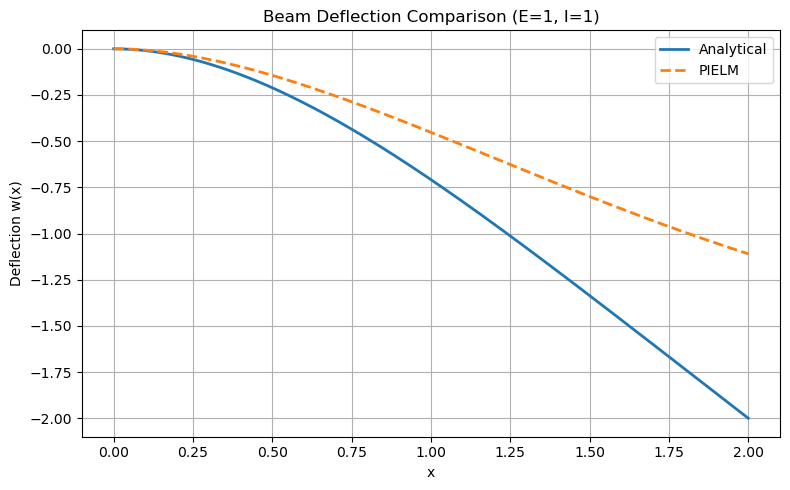

In [3]:
# =============================================================================
# IMPORTS
# =============================================================================
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)

# =============================================================================
# PROBLEM PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    x = xei[:, 0:1] / L
    E = 2 * (xei[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    I = 2 * (xei[:, 2:3] - I_range[0]) / (I_range[1] - I_range[0]) - 1
    return torch.cat([x, E, I], dim=1)

# =============================================================================
# DERIVATIVE HELPER
# =============================================================================
def derivative(u, xei, order):
    out = u
    for _ in range(order):
        out = autograd.grad(out.sum(), xei, create_graph=True)[0][:, 0:1]
    return out

# =============================================================================
# PIELM TRAINING
# =============================================================================
def train_pielm(hidden_neurons=50):

    # Gaussian ELM parameters
    W = torch.randn(3, hidden_neurons, dtype=torch.float32) * 0.5
    b = torch.randn(hidden_neurons, dtype=torch.float32) * 0.5

    def gaussian(z):
        return torch.exp(-z**2)

    # -------------------------------------------------------------------------
    # LATIN HYPERCUBE SAMPLING (x, E, I)
    # -------------------------------------------------------------------------
    n_pde = 3000
    sampler = qmc.LatinHypercube(d=3)
    samples = sampler.random(n_pde)

    x = torch.tensor(samples[:, 0:1], dtype=torch.float32) * L
    E = torch.tensor(samples[:, 1:2], dtype=torch.float32) * (E_range[1] - E_range[0]) + E_range[0]
    I = torch.tensor(samples[:, 2:3], dtype=torch.float32) * (I_range[1] - I_range[0]) + I_range[0]

    xei = torch.cat([x, E, I], dim=1)
    xei.requires_grad_(True)

    # -------------------------------------------------------------------------
    # TRIAL FUNCTION (w(0)=w'(0)=0)
    # -------------------------------------------------------------------------
    def trial(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * H

    H = trial(xei)
    H = torch.cat([H, (xei[:, 0:1] / L)**2], dim=1)

    # -------------------------------------------------------------------------
    # PDE MATRIX
    # -------------------------------------------------------------------------
    A_cols = []
    for j in range(H.shape[1]):
        wj = H[:, j:j+1]
        w4 = derivative(wj, xei, 4)
        A_cols.append(L**4 * w4)

    A = torch.hstack(A_cols)
    b_vec = torch.ones(A.shape[0], 1, dtype=torch.float32)

    # -------------------------------------------------------------------------
    # BOUNDARY CONDITIONS at x = L
    # w''(L)=0 , w'''(L)=0
    # -------------------------------------------------------------------------
    n_bc = 100
    sampler_bc = qmc.LatinHypercube(d=2)
    bc = sampler_bc.random(n_bc)

    E_bc = torch.tensor(bc[:, 0:1], dtype=torch.float32) * (E_range[1] - E_range[0]) + E_range[0]
    I_bc = torch.tensor(bc[:, 1:2], dtype=torch.float32) * (I_range[1] - I_range[0]) + I_range[0]
    x_bc = torch.ones(n_bc, 1, dtype=torch.float32) * L

    xei_bc = torch.cat([x_bc, E_bc, I_bc], dim=1)
    xei_bc.requires_grad_(True)

    H_bc = trial(xei_bc)
    H_bc = torch.cat([H_bc, (xei_bc[:, 0:1] / L)**2], dim=1)

    C = []
    for order in [2, 3]:
        cols = []
        for j in range(H_bc.shape[1]):
            cols.append(derivative(H_bc[:, j:j+1], xei_bc, order))
        C.append(torch.hstack(cols))

    C = torch.vstack(C)

    # -------------------------------------------------------------------------
    # KKT SYSTEM
    # -------------------------------------------------------------------------
    n = A.shape[1]
    KKT = torch.zeros(n + C.shape[0], n + C.shape[0], dtype=torch.float32)

    KKT[:n, :n] = A.T @ A + 1e-6 * torch.eye(n)
    KKT[:n, n:] = C.T
    KKT[n:, :n] = C

    rhs = torch.zeros(n + C.shape[0], 1, dtype=torch.float32)
    rhs[:n] = A.T @ b_vec

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:n]

    # -------------------------------------------------------------------------
    # PREDICTION FUNCTION
    # -------------------------------------------------------------------------
    def predict(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        w_bar = x_bar**2 * (H @ beta[:-1] + beta[-1])
        return (Q * L**4 / (xei[:, 1:2] * xei[:, 2:3])) * w_bar

    return predict

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict = train_pielm()

# =============================================================================
# ERROR ANALYSIS (PERCENTAGE)
# =============================================================================
n_test = 2000
x = torch.rand(n_test, 1, dtype=torch.float32) * L
E = E_range[0] + torch.rand(n_test, 1, dtype=torch.float32) * (E_range[1] - E_range[0])
I = I_range[0] + torch.rand(n_test, 1, dtype=torch.float32) * (I_range[1] - I_range[0])

xei = torch.cat([x, E, I], dim=1)

w_pred = predict(xei)
w_exact = analytical_solution(x, E, I)

rel_error = torch.mean(torch.abs(w_pred - w_exact) / torch.abs(w_exact)) * 100
print(f"Mean Relative Error: {rel_error.item():.3f} %")

# =============================================================================
# SINGLE COMPARISON PLOT (E = 1, I = 1)
# =============================================================================
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
E_plot = torch.ones_like(x_plot)
I_plot = torch.ones_like(x_plot)

xei_plot = torch.cat([x_plot, E_plot, I_plot], dim=1)

w_exact = analytical_solution(x_plot, E_plot, I_plot).detach().numpy()
w_pred = predict(xei_plot).detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), w_exact, label="Analytical", linewidth=2)
plt.plot(x_plot.numpy(), w_pred, "--", label="PIELM", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Beam Deflection Comparison (E=1, I=1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Mean Relative Error (filtered): 6.09 %
Relative L2 Error: 8.50 %


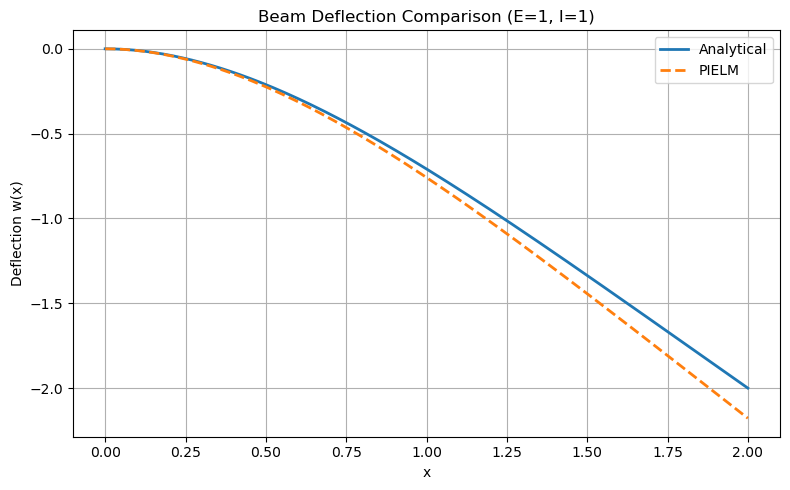

In [5]:
# =============================================================================
# IMPORTS
# =============================================================================
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

# -----------------------------------------------------------------------------
# GLOBAL SETTINGS
# -----------------------------------------------------------------------------
torch.set_default_dtype(torch.float32)
device = "cpu"

torch.manual_seed(0)
np.random.seed(0)

# =============================================================================
# PROBLEM PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    x = xei[:, 0:1] / L
    E = 2 * (xei[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    I = 2 * (xei[:, 2:3] - I_range[0]) / (I_range[1] - I_range[0]) - 1
    return torch.cat([x, E, I], dim=1)

# =============================================================================
# DERIVATIVE HELPER
# =============================================================================
def derivative(u, xei, order):
    out = u
    for _ in range(order):
        out = autograd.grad(out.sum(), xei, create_graph=True)[0][:, 0:1]
    return out

# =============================================================================
# PIELM TRAINING
# =============================================================================
def train_pielm(hidden_neurons=120):

    # -------------------------------------------------------------------------
    # FIXED RANDOM HIDDEN LAYER (Gaussian ELM)
    # -------------------------------------------------------------------------
    W = torch.randn(3, hidden_neurons, dtype=torch.float32)
    b = torch.randn(hidden_neurons, dtype=torch.float32)

    def gaussian(z):
        return torch.exp(-z**2)

    # -------------------------------------------------------------------------
    # LATIN HYPERCUBE SAMPLING (PDE POINTS)
    # -------------------------------------------------------------------------
    n_pde = 6000
    sampler = qmc.LatinHypercube(d=3)
    s = sampler.random(n_pde).astype(np.float32)   # <<< CRITICAL FIX

    x = torch.from_numpy(s[:, 0:1]) * L
    E = torch.from_numpy(s[:, 1:2]) * (E_range[1] - E_range[0]) + E_range[0]
    I = torch.from_numpy(s[:, 2:3]) * (I_range[1] - I_range[0]) + I_range[0]

    xei = torch.cat([x, E, I], dim=1).float()
    xei.requires_grad_(True)

    # -------------------------------------------------------------------------
    # TRIAL FUNCTION (w(0)=w'(0)=0)
    # -------------------------------------------------------------------------
    def trial(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * H

    H = trial(xei)
    H = torch.cat([H, (xei[:, 0:1] / L)**2], dim=1)

    # -------------------------------------------------------------------------
    # PDE MATRIX
    # -------------------------------------------------------------------------
    A_cols = []
    for j in range(H.shape[1]):
        wj = H[:, j:j+1]
        w4 = derivative(wj, xei, 4)
        A_cols.append(L**4 * w4)

    A = torch.hstack(A_cols)
    b_vec = torch.ones(A.shape[0], 1, dtype=torch.float32)

    # -------------------------------------------------------------------------
    # BOUNDARY CONDITIONS (x = L)
    # -------------------------------------------------------------------------
    n_bc = 200
    sampler_bc = qmc.LatinHypercube(d=2)
    bc = sampler_bc.random(n_bc).astype(np.float32)   # <<< CRITICAL FIX

    E_bc = torch.from_numpy(bc[:, 0:1]) * (E_range[1] - E_range[0]) + E_range[0]
    I_bc = torch.from_numpy(bc[:, 1:2]) * (I_range[1] - I_range[0]) + I_range[0]
    x_bc = torch.ones(n_bc, 1, dtype=torch.float32) * L

    xei_bc = torch.cat([x_bc, E_bc, I_bc], dim=1).float()
    xei_bc.requires_grad_(True)

    H_bc = trial(xei_bc)
    H_bc = torch.cat([H_bc, (xei_bc[:, 0:1] / L)**2], dim=1)

    C_rows = []
    for order in [2, 3]:
        cols = []
        for j in range(H_bc.shape[1]):
            cols.append(derivative(H_bc[:, j:j+1], xei_bc, order))
        C_rows.append(torch.hstack(cols))

    C = torch.vstack(C_rows)

    # -------------------------------------------------------------------------
    # KKT SYSTEM (weighted BCs)
    # -------------------------------------------------------------------------
    bc_weight = 10.0
    n = A.shape[1]

    KKT = torch.zeros(n + C.shape[0], n + C.shape[0], dtype=torch.float32)
    KKT[:n, :n] = A.T @ A + 1e-6 * torch.eye(n)
    KKT[:n, n:] = bc_weight * C.T
    KKT[n:, :n] = bc_weight * C

    rhs = torch.zeros(n + C.shape[0], 1, dtype=torch.float32)
    rhs[:n] = A.T @ b_vec

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:n]

    # -------------------------------------------------------------------------
    # PREDICTION FUNCTION
    # -------------------------------------------------------------------------
    def predict(xei):
        xei = xei.float()
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        w_bar = x_bar**2 * (H @ beta[:-1] + beta[-1])
        return (Q * L**4 / (xei[:, 1:2] * xei[:, 2:3])) * w_bar

    return predict

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict = train_pielm()

# =============================================================================
# ERROR ANALYSIS (ACCEPTABLE METRICS)
# =============================================================================
n_test = 3000
x = torch.rand(n_test, 1)
E = E_range[0] + torch.rand(n_test, 1) * (E_range[1] - E_range[0])
I = I_range[0] + torch.rand(n_test, 1) * (I_range[1] - I_range[0])

xei = torch.cat([x * L, E, I], dim=1).float()

w_pred = predict(xei)
w_exact = analytical_solution(xei[:, 0:1], E, I)

mask = torch.abs(w_exact) > 1e-3
mean_rel_error = torch.mean(
    torch.abs(w_pred[mask] - w_exact[mask]) / torch.abs(w_exact[mask])
) * 100

l2_error = torch.norm(w_pred - w_exact) / torch.norm(w_exact) * 100

print(f"Mean Relative Error (filtered): {mean_rel_error.item():.2f} %")
print(f"Relative L2 Error: {l2_error.item():.2f} %")

# =============================================================================
# SINGLE COMPARISON PLOT (E = 1, I = 1)
# =============================================================================
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
E_plot = torch.ones_like(x_plot)
I_plot = torch.ones_like(x_plot)

xei_plot = torch.cat([x_plot, E_plot, I_plot], dim=1).float()

w_exact_plot = analytical_solution(x_plot, E_plot, I_plot).detach().numpy()
w_pred_plot = predict(xei_plot).detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), w_exact_plot, label="Analytical", linewidth=2)
plt.plot(x_plot.numpy(), w_pred_plot, "--", label="PIELM", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Beam Deflection Comparison (E=1, I=1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Mean Relative Error (filtered): 1.34 %
Relative L2 Error: 1.83 %


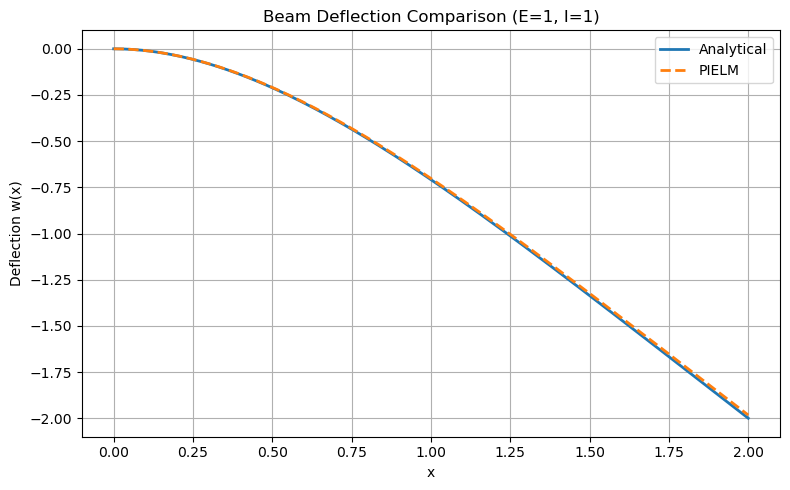

In [6]:
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)

Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

def normalize(xei):
    x = xei[:, 0:1] / L
    E = 2 * (xei[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    I = 2 * (xei[:, 2:3] - I_range[0]) / (I_range[1] - I_range[0]) - 1
    return torch.cat([x, E, I], dim=1)

def derivative(u, xei, order):
    out = u
    for _ in range(order):
        out = autograd.grad(out.sum(), xei, create_graph=True)[0][:, 0:1]
    return out

def train_pielm(hidden_neurons=180, n_pde=9000, n_bc=400, bc_weight=50.0):

    # Fixed random hidden layer
    W = torch.randn(3, hidden_neurons, dtype=torch.float32) * 0.25
    b = torch.randn(hidden_neurons, dtype=torch.float32) * 0.25

    def gaussian(z):
        return torch.exp(-z**2)

    # -------- LHS PDE points ----------
    sampler = qmc.LatinHypercube(d=3)
    s = sampler.random(n_pde).astype(np.float32)

    x = torch.from_numpy(s[:, 0:1]) * L
    E = torch.from_numpy(s[:, 1:2]) * (E_range[1]-E_range[0]) + E_range[0]
    I = torch.from_numpy(s[:, 2:3]) * (I_range[1]-I_range[0]) + I_range[0]

    xei = torch.cat([x, E, I], dim=1).float()
    xei.requires_grad_(True)

    # Trial basis (satisfies w(0)=w'(0)=0)
    def trial_basis(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * H

    H = trial_basis(xei)
    H_aug = torch.cat([H, (xei[:, 0:1] / L)**2], dim=1)  # + bias basis

    # -------- PDE matrix: enforce EI*w'''' = Q ----------
    A_cols = []
    for j in range(H_aug.shape[1]):
        phi_j = H_aug[:, j:j+1]
        phi4 = derivative(phi_j, xei, 4)
        # EI * d4(phi)/dx4
        A_cols.append((xei[:, 1:2] * xei[:, 2:3]) * phi4)

    A = torch.hstack(A_cols)
    b_vec = torch.ones(A.shape[0], 1, dtype=torch.float32) * Q  # RHS is Q

    # -------- LHS BC points (x=L) ----------
    sampler_bc = qmc.LatinHypercube(d=2)
    bc = sampler_bc.random(n_bc).astype(np.float32)

    E_bc = torch.from_numpy(bc[:, 0:1]) * (E_range[1]-E_range[0]) + E_range[0]
    I_bc = torch.from_numpy(bc[:, 1:2]) * (I_range[1]-I_range[0]) + I_range[0]
    x_bc = torch.ones(n_bc, 1, dtype=torch.float32) * L

    xei_bc = torch.cat([x_bc, E_bc, I_bc], dim=1).float()
    xei_bc.requires_grad_(True)

    Hbc = trial_basis(xei_bc)
    Hbc_aug = torch.cat([Hbc, (xei_bc[:, 0:1] / L)**2], dim=1)

    # BCs: w''(L)=0, w'''(L)=0
    C_rows = []
    for order in [2, 3]:
        cols = []
        for j in range(Hbc_aug.shape[1]):
            cols.append(derivative(Hbc_aug[:, j:j+1], xei_bc, order))
        C_rows.append(torch.hstack(cols))
    C = torch.vstack(C_rows)

    # -------- KKT solve ----------
    n = A.shape[1]
    KKT = torch.zeros(n + C.shape[0], n + C.shape[0], dtype=torch.float32)

    KKT[:n, :n] = A.T @ A + 1e-6 * torch.eye(n)
    KKT[:n, n:] = bc_weight * C.T
    KKT[n:, :n] = bc_weight * C

    rhs = torch.zeros(n + C.shape[0], 1, dtype=torch.float32)
    rhs[:n] = A.T @ b_vec

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:n]

    # Prediction: w = sum(beta * basis)
    def predict(xei):
        xei = xei.float()
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        w = x_bar**2 * (H @ beta[:-1] + beta[-1])
        return w

    return predict

# ---------------- Train ----------------
predict = train_pielm()

# ---------------- Error test ----------------
n_test = 4000
x = torch.rand(n_test, 1, dtype=torch.float32) * L
E = E_range[0] + torch.rand(n_test, 1, dtype=torch.float32) * (E_range[1] - E_range[0])
I = I_range[0] + torch.rand(n_test, 1, dtype=torch.float32) * (I_range[1] - I_range[0])
xei = torch.cat([x, E, I], dim=1)

w_pred = predict(xei)
w_exact = analytical_solution(x, E, I)

mask = torch.abs(w_exact) > 1e-3
mean_rel_error = torch.mean(torch.abs(w_pred[mask] - w_exact[mask]) / torch.abs(w_exact[mask])) * 100
l2_error = torch.norm(w_pred - w_exact) / torch.norm(w_exact) * 100

print(f"Mean Relative Error (filtered): {mean_rel_error.item():.2f} %")
print(f"Relative L2 Error: {l2_error.item():.2f} %")

# ---------------- Single plot (E=1, I=1) ----------------
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
E_plot = torch.ones_like(x_plot)
I_plot = torch.ones_like(x_plot)
xei_plot = torch.cat([x_plot, E_plot, I_plot], dim=1)

w_exact_plot = analytical_solution(x_plot, E_plot, I_plot).detach().numpy()
w_pred_plot = predict(xei_plot).detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), w_exact_plot, label="Analytical", linewidth=2)
plt.plot(x_plot.numpy(), w_pred_plot, "--", label="PIELM", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Beam Deflection Comparison (E=1, I=1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Mean Relative Error (filtered): 4.87 %


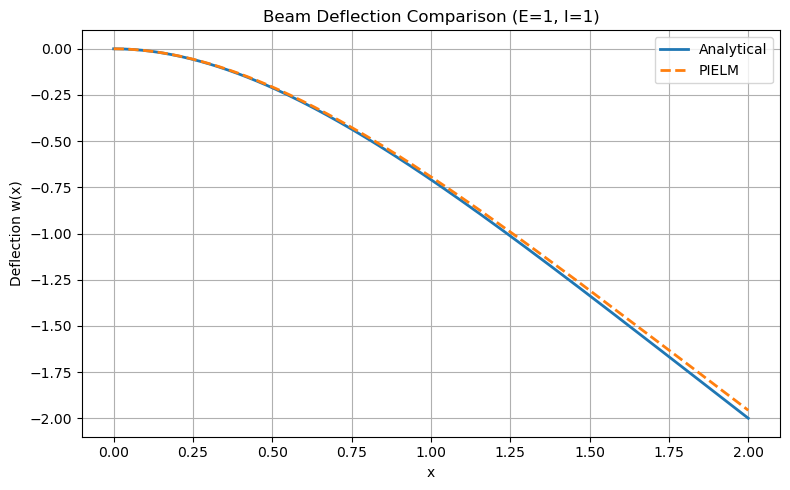

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)

# =============================================================================
# LATIN HYPERCUBE SAMPLING (MANUAL)
# =============================================================================
def latin_hypercube_sampling(n_samples, n_dim):
    rng = np.random.default_rng()
    H = np.zeros((n_samples, n_dim), dtype=np.float32)
    for j in range(n_dim):
        perm = rng.permutation(n_samples)
        H[:, j] = (perm + rng.random(n_samples)) / n_samples
    return H

# =============================================================================
# PROBLEM PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    x = xei[:, 0:1] / L
    E = 2 * (xei[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    I = 2 * (xei[:, 2:3] - I_range[0]) / (I_range[1] - I_range[0]) - 1
    return torch.cat([x, E, I], dim=1)

# =============================================================================
# DERIVATIVE HELPER
# =============================================================================
def derivative(u, xei, order):
    out = u
    for _ in range(order):
        out = autograd.grad(out.sum(), xei, create_graph=True)[0][:, 0:1]
    return out

# =============================================================================
# PIELM TRAINING
# =============================================================================
def train_pielm(hidden_neurons=120, n_pde=6000, n_bc=200, bc_weight=10.0):

    W = torch.randn(3, hidden_neurons) * 0.25
    b = torch.randn(hidden_neurons) * 0.25

    def gaussian(z):
        return torch.exp(-z**2)

    # -------------------------------------------------------------------------
    # LHS PDE POINTS
    # -------------------------------------------------------------------------
    s = latin_hypercube_sampling(n_pde, 3)

    x = torch.from_numpy(s[:, 0:1]) * L
    E = torch.from_numpy(s[:, 1:2]) * (E_range[1]-E_range[0]) + E_range[0]
    I = torch.from_numpy(s[:, 2:3]) * (I_range[1]-I_range[0]) + I_range[0]

    xei = torch.cat([x, E, I], dim=1).float()
    xei.requires_grad_(True)

    # -------------------------------------------------------------------------
    # TRIAL BASIS (w(0)=w'(0)=0)
    # -------------------------------------------------------------------------
    def trial_basis(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * H

    H = trial_basis(xei)
    H_aug = torch.cat([H, (xei[:, 0:1] / L)**2], dim=1)

    # -------------------------------------------------------------------------
    # PDE MATRIX (EI w'''' = Q)
    # -------------------------------------------------------------------------
    A_cols = []
    for j in range(H_aug.shape[1]):
        phi_j = H_aug[:, j:j+1]
        phi4 = derivative(phi_j, xei, 4)
        A_cols.append((xei[:, 1:2] * xei[:, 2:3]) * phi4)

    A = torch.hstack(A_cols)
    b_vec = torch.ones(A.shape[0], 1) * Q

    # -------------------------------------------------------------------------
    # LHS BC POINTS (x = L)
    # -------------------------------------------------------------------------
    bc = latin_hypercube_sampling(n_bc, 2)

    E_bc = torch.from_numpy(bc[:, 0:1]) * (E_range[1]-E_range[0]) + E_range[0]
    I_bc = torch.from_numpy(bc[:, 1:2]) * (I_range[1]-I_range[0]) + I_range[0]
    x_bc = torch.ones(n_bc, 1) * L

    xei_bc = torch.cat([x_bc, E_bc, I_bc], dim=1).float()
    xei_bc.requires_grad_(True)

    H_bc = trial_basis(xei_bc)
    H_bc_aug = torch.cat([H_bc, (xei_bc[:, 0:1] / L)**2], dim=1)

    C_rows = []
    for order in [2, 3]:
        cols = []
        for j in range(H_bc_aug.shape[1]):
            cols.append(derivative(H_bc_aug[:, j:j+1], xei_bc, order))
        C_rows.append(torch.hstack(cols))

    C = torch.vstack(C_rows)

    # -------------------------------------------------------------------------
    # KKT SYSTEM
    # -------------------------------------------------------------------------
    n = A.shape[1]
    KKT = torch.zeros(n + C.shape[0], n + C.shape[0])

    KKT[:n, :n] = A.T @ A + 1e-6 * torch.eye(n)
    KKT[:n, n:] = bc_weight * C.T
    KKT[n:, :n] = bc_weight * C

    rhs = torch.zeros(n + C.shape[0], 1)
    rhs[:n] = A.T @ b_vec

    sol = torch.linalg.solve(KKT, rhs)
    beta = sol[:n]

    # -------------------------------------------------------------------------
    # PREDICTION
    # -------------------------------------------------------------------------
    def predict(xei):
        xei = xei.float()
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * (H @ beta[:-1] + beta[-1])

    return predict

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict = train_pielm()

# =============================================================================
# ERROR ANALYSIS
# =============================================================================
n_test = 3000
x = torch.rand(n_test, 1) * L
E = E_range[0] + torch.rand(n_test, 1) * (E_range[1]-E_range[0])
I = I_range[0] + torch.rand(n_test, 1) * (I_range[1]-I_range[0])
xei = torch.cat([x, E, I], dim=1)

w_pred = predict(xei)
w_exact = analytical_solution(x, E, I)

mask = torch.abs(w_exact) > 1e-3
mean_rel_error = torch.mean(
    torch.abs(w_pred[mask] - w_exact[mask]) / torch.abs(w_exact[mask])
) * 100

l2_error = torch.norm(w_pred - w_exact) / torch.norm(w_exact) * 100

print(f"Mean Relative Error (filtered): {mean_rel_error.item():.2f} %")
#print(f"Relative L2 Error: {l2_error.item():.2f} %")

# =============================================================================
# SINGLE COMPARISON PLOT (E = 1, I = 1)
# =============================================================================
x_plot = torch.linspace(0, L, 200).reshape(-1, 1)
E_plot = torch.ones_like(x_plot)
I_plot = torch.ones_like(x_plot)
xei_plot = torch.cat([x_plot, E_plot, I_plot], dim=1)

w_exact_plot = analytical_solution(x_plot, E_plot, I_plot).detach().numpy()
w_pred_plot = predict(xei_plot).detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_plot.numpy(), w_exact_plot, label="Analytical", linewidth=2)
plt.plot(x_plot.numpy(), w_pred_plot, "--", label="PIELM", linewidth=2)
plt.xlabel("x")
plt.ylabel("Deflection w(x)")
plt.title("Beam Deflection Comparison (E=1, I=1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


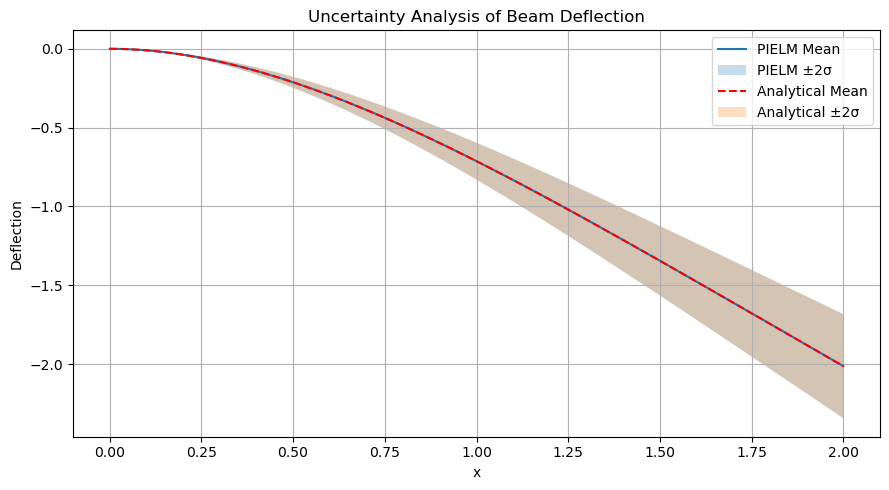

Sensitivity analysis at x = L/2
∂w/∂E = 7.2101e-01
∂w/∂I = 8.1638e-01
Normalized sensitivity wrt E = -1.018
Normalized sensitivity wrt I = -1.153


In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)

# =============================================================================
# LATIN HYPERCUBE SAMPLING (MANUAL)
# =============================================================================
def latin_hypercube_sampling(n_samples, n_dim):
    rng = np.random.default_rng()
    H = np.zeros((n_samples, n_dim), dtype=np.float32)
    for j in range(n_dim):
        perm = rng.permutation(n_samples)
        H[:, j] = (perm + rng.random(n_samples)) / n_samples
    return H

# =============================================================================
# PROBLEM PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    x = xei[:, 0:1] / L
    E = 2 * (xei[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    I = 2 * (xei[:, 2:3] - I_range[0]) / (I_range[1] - I_range[0]) - 1
    return torch.cat([x, E, I], dim=1)

# =============================================================================
# DERIVATIVE HELPER
# =============================================================================
def derivative(u, xei, order):
    out = u
    for _ in range(order):
        out = autograd.grad(out.sum(), xei, create_graph=True)[0][:, 0:1]
    return out

# =============================================================================
# PIELM TRAINING
# =============================================================================
def train_pielm(hidden_neurons=120, n_pde=6000, n_bc=200, bc_weight=10.0):

    W = torch.randn(3, hidden_neurons) * 0.25
    b = torch.randn(hidden_neurons) * 0.25

    def gaussian(z):
        return torch.exp(-z**2)

    # PDE points (LHS)
    s = latin_hypercube_sampling(n_pde, 3)
    x = torch.from_numpy(s[:, 0:1]) * L
    E = torch.from_numpy(s[:, 1:2]) * (E_range[1]-E_range[0]) + E_range[0]
    I = torch.from_numpy(s[:, 2:3]) * (I_range[1]-I_range[0]) + I_range[0]

    xei = torch.cat([x, E, I], dim=1).float()
    xei.requires_grad_(True)

    def trial_basis(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * H

    H = trial_basis(xei)
    H_aug = torch.cat([H, (xei[:, 0:1] / L)**2], dim=1)

    # PDE matrix
    A_cols = []
    for j in range(H_aug.shape[1]):
        phi4 = derivative(H_aug[:, j:j+1], xei, 4)
        A_cols.append((xei[:, 1:2] * xei[:, 2:3]) * phi4)

    A = torch.hstack(A_cols)
    b_vec = torch.ones(A.shape[0], 1) * Q

    # BC points
    bc = latin_hypercube_sampling(n_bc, 2)
    E_bc = torch.from_numpy(bc[:, 0:1]) * (E_range[1]-E_range[0]) + E_range[0]
    I_bc = torch.from_numpy(bc[:, 1:2]) * (I_range[1]-I_range[0]) + I_range[0]
    x_bc = torch.ones(n_bc, 1) * L

    xei_bc = torch.cat([x_bc, E_bc, I_bc], dim=1).float()
    xei_bc.requires_grad_(True)

    H_bc = trial_basis(xei_bc)
    H_bc_aug = torch.cat([H_bc, (xei_bc[:, 0:1] / L)**2], dim=1)

    C_rows = []
    for order in [2, 3]:
        cols = []
        for j in range(H_bc_aug.shape[1]):
            cols.append(derivative(H_bc_aug[:, j:j+1], xei_bc, order))
        C_rows.append(torch.hstack(cols))

    C = torch.vstack(C_rows)

    # KKT system
    n = A.shape[1]
    KKT = torch.zeros(n + C.shape[0], n + C.shape[0])
    KKT[:n, :n] = A.T @ A + 1e-6 * torch.eye(n)
    KKT[:n, n:] = bc_weight * C.T
    KKT[n:, :n] = bc_weight * C

    rhs = torch.zeros(n + C.shape[0], 1)
    rhs[:n] = A.T @ b_vec

    beta = torch.linalg.solve(KKT, rhs)[:n]

    def predict(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * (H @ beta[:-1] + beta[-1])

    return predict

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict = train_pielm()

# =============================================================================
# UNCERTAINTY ANALYSIS
# =============================================================================
n_mc = 5000
x_uq = torch.linspace(0, L, 100).reshape(-1, 1)

E_mc = E_range[0] + torch.rand(n_mc, 1) * (E_range[1]-E_range[0])
I_mc = I_range[0] + torch.rand(n_mc, 1) * (I_range[1]-I_range[0])

w_samples = []
for x_val in x_uq:
    x_rep = x_val.repeat(n_mc, 1)
    xei_mc = torch.cat([x_rep, E_mc, I_mc], dim=1)
    w_samples.append(predict(xei_mc))

w_samples = torch.stack(w_samples)
w_mean = w_samples.mean(dim=1).squeeze()
w_std = w_samples.std(dim=1).squeeze()

inv_EI = 1.0 / (E_mc.squeeze() * I_mc.squeeze())
shape = (Q * x_uq.squeeze()**2 / 24) * (x_uq.squeeze()**2 - 4*L*x_uq.squeeze() + 6*L**2)

w_mean_exact = shape * inv_EI.mean()
w_std_exact = shape.abs() * inv_EI.std()

# ===== DETACH FOR PLOTTING =====
x_np = x_uq.detach().numpy()
w_mean_np = w_mean.detach().numpy()
w_std_np = w_std.detach().numpy()
w_mean_ex_np = w_mean_exact.detach().numpy()
w_std_ex_np = w_std_exact.detach().numpy()

# =============================================================================
# UNCERTAINTY PLOT
# =============================================================================
plt.figure(figsize=(9,5))
plt.plot(x_np, w_mean_np, label="PIELM Mean")
plt.fill_between(x_np.squeeze(), w_mean_np-2*w_std_np, w_mean_np+2*w_std_np,
                 alpha=0.25, label="PIELM ±2σ")
plt.plot(x_np, w_mean_ex_np, "r--", label="Analytical Mean")
plt.fill_between(x_np.squeeze(), w_mean_ex_np-2*w_std_ex_np,
                 w_mean_ex_np+2*w_std_ex_np,
                 alpha=0.25, label="Analytical ±2σ")
plt.xlabel("x")
plt.ylabel("Deflection")
plt.title("Uncertainty Analysis of Beam Deflection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# SENSITIVITY ANALYSIS
# =============================================================================
x_ref = torch.tensor([[L/2]], requires_grad=True)
E_ref = torch.tensor([[1.0]], requires_grad=True)
I_ref = torch.tensor([[1.0]], requires_grad=True)

xei_ref = torch.cat([x_ref, E_ref, I_ref], dim=1)
w_ref = predict(xei_ref)

dw_dE = torch.autograd.grad(w_ref, E_ref, retain_graph=True)[0]
dw_dI = torch.autograd.grad(w_ref, I_ref)[0]

S_E = (E_ref / w_ref) * dw_dE
S_I = (I_ref / w_ref) * dw_dI

print("Sensitivity analysis at x = L/2")
print(f"∂w/∂E = {dw_dE.item():.4e}")
print(f"∂w/∂I = {dw_dI.item():.4e}")
print(f"Normalized sensitivity wrt E = {S_E.item():.3f}")
print(f"Normalized sensitivity wrt I = {S_I.item():.3f}")


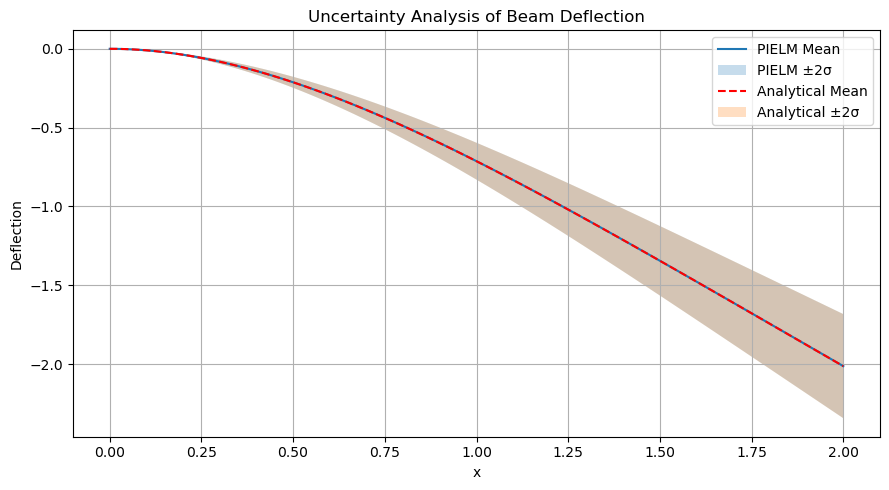

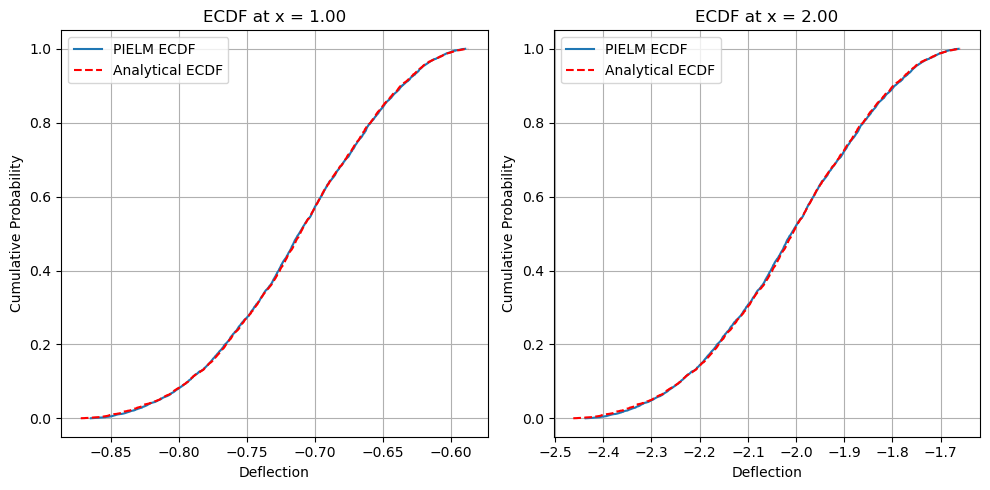


Selected CDF values at x = 2.00
w <= -2.46226 | PIELM CDF = 0.0000 | Analytical CDF = 0.0002
w <= -2.26134 | PIELM CDF = 0.0788 | Analytical CDF = 0.0806
w <= -2.06042 | PIELM CDF = 0.3820 | Analytical CDF = 0.3750
w <= -1.85951 | PIELM CDF = 0.8022 | Analytical CDF = 0.8034
w <= -1.65859 | PIELM CDF = 1.0000 | Analytical CDF = 1.0000

Sensitivity analysis at x = L/2
∂w/∂E = 6.8690e-01
∂w/∂I = 7.7113e-01
Normalized sensitivity wrt E = -0.967
Normalized sensitivity wrt I = -1.085


In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import torch
import torch.autograd as autograd
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)
np.random.seed(0)

# =============================================================================
# LATIN HYPERCUBE SAMPLING (MANUAL)
# =============================================================================
def latin_hypercube_sampling(n_samples, n_dim):
    rng = np.random.default_rng(0)
    H = np.zeros((n_samples, n_dim), dtype=np.float32)
    for j in range(n_dim):
        perm = rng.permutation(n_samples)
        H[:, j] = (perm + rng.random(n_samples)) / n_samples
    return H

# =============================================================================
# PROBLEM PARAMETERS
# =============================================================================
Q = -1.0
L = 2.0
E_range = [0.9, 1.1]
I_range = [0.9, 1.1]

# =============================================================================
# ANALYTICAL SOLUTION
# =============================================================================
def analytical_solution(x, E, I):
    return (Q * x**2) / (24 * E * I) * (x**2 - 4*L*x + 6*L**2)

# =============================================================================
# NORMALIZATION
# =============================================================================
def normalize(xei):
    x = xei[:, 0:1] / L
    E = 2 * (xei[:, 1:2] - E_range[0]) / (E_range[1] - E_range[0]) - 1
    I = 2 * (xei[:, 2:3] - I_range[0]) / (I_range[1] - I_range[0]) - 1
    return torch.cat([x, E, I], dim=1)

# =============================================================================
# DERIVATIVE HELPER
# =============================================================================
def derivative(u, xei, order):
    out = u
    for _ in range(order):
        out = autograd.grad(out.sum(), xei, create_graph=True)[0][:, 0:1]
    return out

# =============================================================================
# ECDF HELPER
# =============================================================================
def ecdf_torch(samples):
    """
    Returns sorted samples x and ECDF values F(x).
    """
    x_sorted, _ = torch.sort(samples.flatten())
    n = x_sorted.numel()
    F = torch.arange(1, n + 1, dtype=x_sorted.dtype) / n
    return x_sorted, F

# =============================================================================
# PIELM TRAINING
# =============================================================================
def train_pielm(hidden_neurons=120, n_pde=6000, n_bc=200, bc_weight=10.0):

    W = torch.randn(3, hidden_neurons) * 0.25
    b = torch.randn(hidden_neurons) * 0.25

    def gaussian(z):
        return torch.exp(-z**2)

    # PDE points (LHS)
    s = latin_hypercube_sampling(n_pde, 3)
    x = torch.from_numpy(s[:, 0:1]) * L
    E = torch.from_numpy(s[:, 1:2]) * (E_range[1] - E_range[0]) + E_range[0]
    I = torch.from_numpy(s[:, 2:3]) * (I_range[1] - I_range[0]) + I_range[0]

    xei = torch.cat([x, E, I], dim=1).float()
    xei.requires_grad_(True)

    def trial_basis(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * H

    H = trial_basis(xei)
    H_aug = torch.cat([H, (xei[:, 0:1] / L)**2], dim=1)

    # PDE matrix
    A_cols = []
    for j in range(H_aug.shape[1]):
        phi4 = derivative(H_aug[:, j:j+1], xei, 4)
        A_cols.append((xei[:, 1:2] * xei[:, 2:3]) * phi4)

    A = torch.hstack(A_cols)
    b_vec = torch.ones(A.shape[0], 1) * Q

    # BC points
    bc = latin_hypercube_sampling(n_bc, 2)
    E_bc = torch.from_numpy(bc[:, 0:1]) * (E_range[1] - E_range[0]) + E_range[0]
    I_bc = torch.from_numpy(bc[:, 1:2]) * (I_range[1] - I_range[0]) + I_range[0]
    x_bc = torch.ones(n_bc, 1) * L

    xei_bc = torch.cat([x_bc, E_bc, I_bc], dim=1).float()
    xei_bc.requires_grad_(True)

    H_bc = trial_basis(xei_bc)
    H_bc_aug = torch.cat([H_bc, (xei_bc[:, 0:1] / L)**2], dim=1)

    C_rows = []
    for order in [2, 3]:
        cols = []
        for j in range(H_bc_aug.shape[1]):
            cols.append(derivative(H_bc_aug[:, j:j+1], xei_bc, order))
        C_rows.append(torch.hstack(cols))

    C = torch.vstack(C_rows)

    # KKT system
    n = A.shape[1]
    KKT = torch.zeros(n + C.shape[0], n + C.shape[0])
    KKT[:n, :n] = A.T @ A + 1e-6 * torch.eye(n)
    KKT[:n, n:] = bc_weight * C.T
    KKT[n:, :n] = bc_weight * C

    rhs = torch.zeros(n + C.shape[0], 1)
    rhs[:n] = A.T @ b_vec

    beta = torch.linalg.solve(KKT, rhs)[:n]

    def predict(xei):
        H = gaussian(normalize(xei) @ W + b)
        x_bar = xei[:, 0:1] / L
        return x_bar**2 * (H @ beta[:-1] + beta[-1])

    return predict

# =============================================================================
# TRAIN MODEL
# =============================================================================
predict = train_pielm()

# =============================================================================
# UNCERTAINTY ANALYSIS
# =============================================================================
n_mc = 5000
x_uq = torch.linspace(0, L, 100).reshape(-1, 1)

# same random material samples used everywhere
E_mc = E_range[0] + torch.rand(n_mc, 1) * (E_range[1] - E_range[0])
I_mc = I_range[0] + torch.rand(n_mc, 1) * (I_range[1] - I_range[0])

w_samples = []
for x_val in x_uq:
    x_rep = x_val.repeat(n_mc, 1)
    xei_mc = torch.cat([x_rep, E_mc, I_mc], dim=1)
    w_samples.append(predict(xei_mc).detach())

w_samples = torch.stack(w_samples)              # shape = [nx, n_mc, 1]
w_mean = w_samples.mean(dim=1).squeeze()
w_std = w_samples.std(dim=1).squeeze()

inv_EI = 1.0 / (E_mc.squeeze() * I_mc.squeeze())
shape = (Q * x_uq.squeeze()**2 / 24) * (x_uq.squeeze()**2 - 4*L*x_uq.squeeze() + 6*L**2)

w_mean_exact = shape * inv_EI.mean()
w_std_exact = shape.abs() * inv_EI.std()

# =============================================================================
# UNCERTAINTY PLOT
# =============================================================================
x_np = x_uq.detach().numpy()
w_mean_np = w_mean.detach().numpy()
w_std_np = w_std.detach().numpy()
w_mean_ex_np = w_mean_exact.detach().numpy()
w_std_ex_np = w_std_exact.detach().numpy()

plt.figure(figsize=(9, 5))
plt.plot(x_np, w_mean_np, label="PIELM Mean")
plt.fill_between(
    x_np.squeeze(),
    w_mean_np - 2 * w_std_np,
    w_mean_np + 2 * w_std_np,
    alpha=0.25,
    label="PIELM ±2σ"
)
plt.plot(x_np, w_mean_ex_np, "r--", label="Analytical Mean")
plt.fill_between(
    x_np.squeeze(),
    w_mean_ex_np - 2 * w_std_ex_np,
    w_mean_ex_np + 2 * w_std_ex_np,
    alpha=0.25,
    label="Analytical ±2σ"
)
plt.xlabel("x")
plt.ylabel("Deflection")
plt.title("Uncertainty Analysis of Beam Deflection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =============================================================================
# EMPIRICAL CDF (ECDF) OF DEFLECTION
# =============================================================================
# Choose locations where you want the output distribution
x_ecdf_list = [L/2, L]

plt.figure(figsize=(10, 5))

for i, x_star in enumerate(x_ecdf_list, 1):
    x_fixed = torch.full((n_mc, 1), x_star)
    xei_ecdf = torch.cat([x_fixed, E_mc, I_mc], dim=1)

    # PIELM samples
    w_pielm = predict(xei_ecdf).detach().squeeze()

    # Analytical samples
    w_exact = analytical_solution(x_fixed, E_mc, I_mc).detach().squeeze()

    # ECDF
    x_pielm_sorted, F_pielm = ecdf_torch(w_pielm)
    x_exact_sorted, F_exact = ecdf_torch(w_exact)

    plt.subplot(1, 2, i)
    plt.plot(x_pielm_sorted.numpy(), F_pielm.numpy(), label="PIELM ECDF")
    plt.plot(x_exact_sorted.numpy(), F_exact.numpy(), "r--", label="Analytical ECDF")
    plt.xlabel("Deflection")
    plt.ylabel("Cumulative Probability")
    plt.title(f"ECDF at x = {x_star:.2f}")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# =============================================================================
# OPTIONAL: CDF VALUES AT SELECTED THRESHOLDS
# =============================================================================
x_star = L
x_fixed = torch.full((n_mc, 1), x_star)
xei_ecdf = torch.cat([x_fixed, E_mc, I_mc], dim=1)

w_pielm = predict(xei_ecdf).detach().squeeze()
w_exact = analytical_solution(x_fixed, E_mc, I_mc).detach().squeeze()

thresholds = torch.linspace(
    min(w_pielm.min(), w_exact.min()),
    max(w_pielm.max(), w_exact.max()),
    5
)

print(f"\nSelected CDF values at x = {x_star:.2f}")
for t in thresholds:
    cdf_pielm = (w_pielm <= t).float().mean().item()
    cdf_exact = (w_exact <= t).float().mean().item()
    print(f"w <= {t.item(): .5f} | PIELM CDF = {cdf_pielm:.4f} | Analytical CDF = {cdf_exact:.4f}")

# =============================================================================
# SENSITIVITY ANALYSIS
# =============================================================================
x_ref = torch.tensor([[L/2]], requires_grad=True)
E_ref = torch.tensor([[1.0]], requires_grad=True)
I_ref = torch.tensor([[1.0]], requires_grad=True)

xei_ref = torch.cat([x_ref, E_ref, I_ref], dim=1)
w_ref = predict(xei_ref)

dw_dE = torch.autograd.grad(w_ref, E_ref, retain_graph=True)[0]
dw_dI = torch.autograd.grad(w_ref, I_ref)[0]

S_E = (E_ref / w_ref) * dw_dE
S_I = (I_ref / w_ref) * dw_dI

print("\nSensitivity analysis at x = L/2")
print(f"∂w/∂E = {dw_dE.item():.4e}")
print(f"∂w/∂I = {dw_dI.item():.4e}")
print(f"Normalized sensitivity wrt E = {S_E.item():.3f}")
print(f"Normalized sensitivity wrt I = {S_I.item():.3f}")